# Machine Learning & NLP 
## Teoria, Algoritmos e Implementacion

> **Fuentes teoricas principales:**
> - Shalev-Shwartz & Ben-David (2014) — *Understanding Machine Learning: From Theory to Algorithms* (Cambridge UP)
> - James, Witten, Hastie, Tibshirani (2023) — *ISLP* (https://www.statlearning.com)
> - Carolyn Wang — *Exploring ML and NLP as a High School Student* (Towards Data Science)

---

**Estructura Completa:**

| Bloque | Tema | Min |
|--------|------|-----|
| **1** | KNN: Teoria, Parametros, Curse of Dimensionality | 15 |
| **2** | Bias-Variance Tradeoff: Descomposicion Formal del Error | 15 |
| **3** | Model Selection: Train/Val/Test, K-Fold CV, Data Leakage | 20 |
| **4** | Regresion Lineal: OLS, Supuestos, Gradient Descent | 20 |
| **5** | Arboles de Decision: Gini, Entropia, ID3, Pruning, Random Forest | 15 |
| **6** | Reduccion de Dimensionalidad: PCA Formal | 10 |
| **7** | Series de Tiempo y Cadenas de Markov | 15 |
| **8** | NLP: Tokenizacion, BoW, TF-IDF, Semantica | 20 |
| **9** | Pipeline NLP Completo: Sentiment Analysis | 20 |


In [29]:
# ============================================================
# CELDA 0: IMPORTS Y CONFIGURACION GLOBAL
# ============================================================
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import re

from sklearn.model_selection import (train_test_split, cross_val_score,
                                      StratifiedKFold, KFold,
                                      RandomizedSearchCV, learning_curve)
from sklearn.preprocessing import (StandardScaler, MinMaxScaler,
                                    PolynomialFeatures)
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.linear_model import (LinearRegression, LogisticRegression,
                                   Ridge, Lasso)
from sklearn.tree import (DecisionTreeClassifier, DecisionTreeRegressor,
                           export_text)
from sklearn.ensemble import (RandomForestClassifier,
                               GradientBoostingClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn import tree as sktree

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, accuracy_score,
    confusion_matrix, classification_report, roc_curve, auc,
    mean_squared_error, r2_score, f1_score, precision_recall_curve,
    ConfusionMatrixDisplay, precision_score, recall_score, log_loss)

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.datasets import load_iris, make_moons, make_classification
from sklearn.metrics import pairwise_distances
from scipy.stats import randint, uniform

np.random.seed(42)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
sns.set_palette('tab10')
print("Imports completados | NumPy", np.__version__, "| Pandas", pd.__version__)


Imports completados | NumPy 2.4.1 | Pandas 3.0.0


---
# Bloque 1 — K-Nearest Neighbors: Teoria Completa

## Fundamento Teorico (Shalev-Shwartz & Ben-David, Cap. 19)

### Definicion Formal

Dado un espacio metrico $(\mathcal{X}, \rho)$ y una muestra $S = \{(x_i, y_i)\}_{i=1}^m$:

$$h_S(x) = \text{majority}\{y_{\pi_i(x)} : i \leq k\}$$

donde $\pi_1(x),...,\pi_m(x)$ es un reordenamiento de $\{1,...,m\}$ tal que $\rho(x, x_{\pi_i}) \leq \rho(x, x_{\pi_{i+1}})$.


### Parametros e Hiperparametros

| Elemento | Tipo | Valores | Efecto |
|----------|------|---------|--------|
| **K** | Hiperparametro | $1,...,n$ | Bias-variance: K↑ = mas bias, menos varianza |
| **Metrica $\rho$** | Hiperparametro | Euclidiana, Manhattan, Minkowski | Forma del vecindario |
| **Pesos** | Hiperparametro | uniform, distance | Ponderar por distancia |
| **p (Minkowski)** | Hiperparametro | $p \geq 1$ | $p=2$: Euclidiana, $p=1$: Manhattan |

### Funcion de Perdida
No tiene loss function explicita en entrenamiento (lazy learner). La evaluacion usa:
$$L_\mathcal{D}(h_S) = \mathbb{P}_{x\sim\mathcal{D}}[h_S(x) \neq y]$$

### Pregunta Clase
> *¿Por que KNN es sensible a features no escaladas?*
> **R:** La distancia Euclidiana $\sqrt{\sum(x_j - z_j)^2}$ esta dominada por features con mayor rango.
> Sin escalar, Age∈[0,100] es ignorada frente a Salary∈[0,200000].


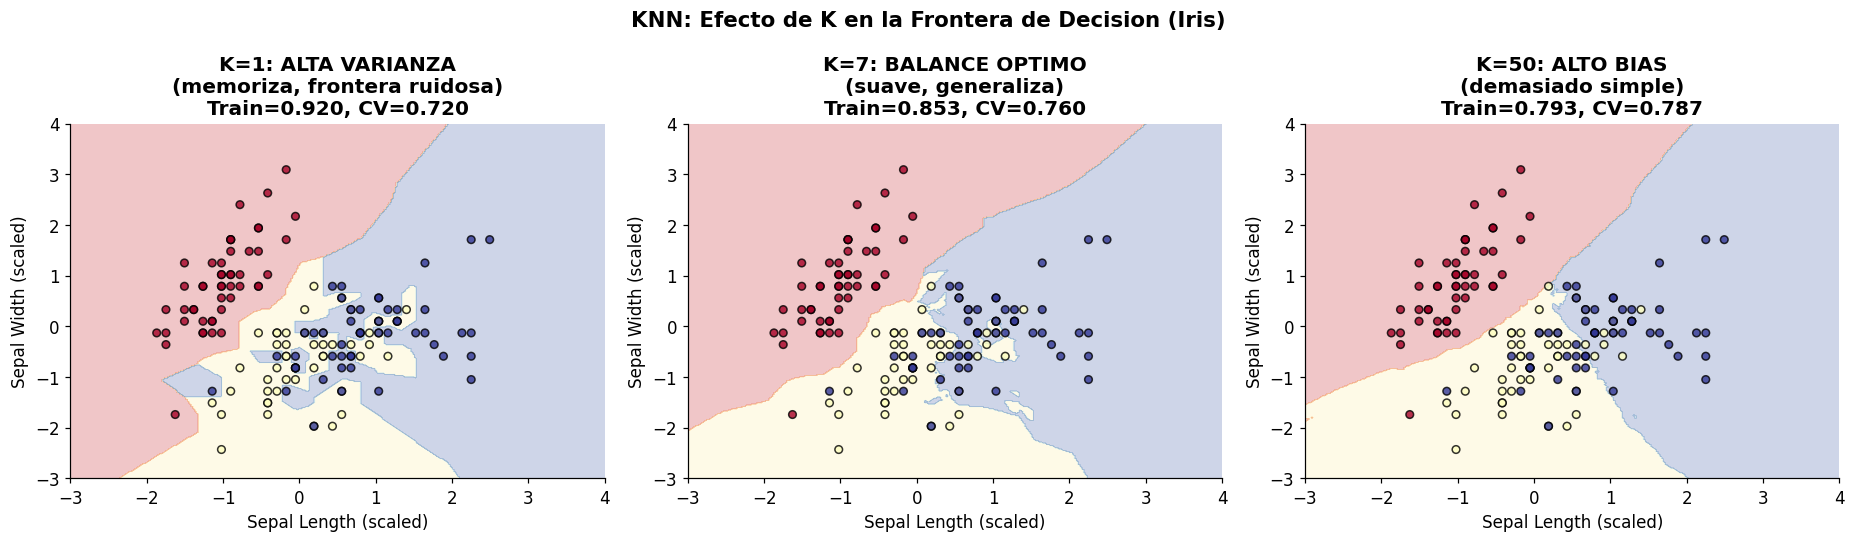

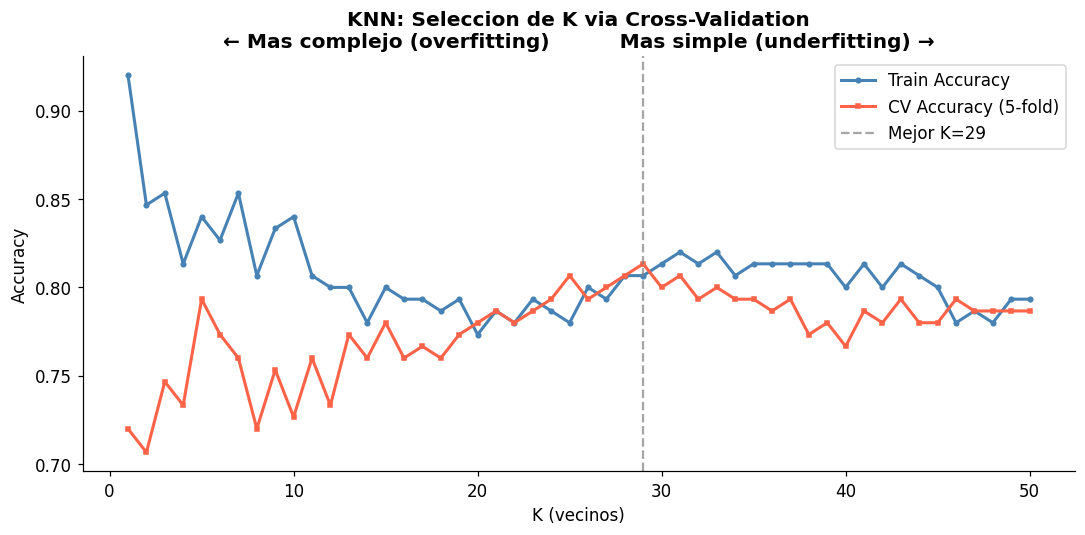

Mejor K=29, CV Accuracy=0.8133


In [32]:
# --- KNN: Implementacion completa con Iris ---
iris = load_iris()
X_iris = iris.data[:, :2]  # 2 features para visualizar
y_iris = iris.target
scaler_knn = StandardScaler()
X_iris_sc = scaler_knn.fit_transform(X_iris)

# === Fronteras de decision para K=1, 7, 50 ===
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
Ks = [1, 7, 50]
titles = ['K=1: ALTA VARIANZA\n(memoriza, frontera ruidosa)',
          'K=7: BALANCE OPTIMO\n(suave, generaliza)',
          'K=50: ALTO BIAS\n(demasiado simple)']

for ax, k, title in zip(axes, Ks, titles):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_iris_sc, y_iris)
    xx, yy = np.meshgrid(np.linspace(-3, 4, 300), np.linspace(-3, 4, 300))
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap='RdYlBu')
    ax.scatter(X_iris_sc[:,0], X_iris_sc[:,1], c=y_iris,
               cmap='RdYlBu', edgecolors='k', s=25, alpha=0.8)
    tr_acc = accuracy_score(y_iris, knn.predict(X_iris_sc))
    cv_acc = cross_val_score(knn, X_iris_sc, y_iris, cv=5).mean()
    ax.set_title(f'{title}\nTrain={tr_acc:.3f}, CV={cv_acc:.3f}', fontweight='bold')
    ax.set_xlabel('Sepal Length (scaled)'); ax.set_ylabel('Sepal Width (scaled)')

plt.suptitle('KNN: Efecto de K en la Frontera de Decision (Iris)',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# === Curva de seleccion de K ===
k_range = range(1, 51)
cv_scores = [cross_val_score(
    make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k)),
    X_iris, y_iris, cv=5).mean() for k in k_range]
train_scores = []
for k in k_range:
    m = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    m.fit(X_iris, y_iris)
    train_scores.append(accuracy_score(y_iris, m.predict(X_iris)))

best_k = list(k_range)[np.argmax(cv_scores)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_range, train_scores, 'o-', color='steelblue', lw=2, ms=3, label='Train Accuracy')
ax.plot(k_range, cv_scores, 's-', color='tomato', lw=2, ms=3, label='CV Accuracy (5-fold)')
ax.axvline(best_k, color='gray', ls='--', alpha=0.7, label=f'Mejor K={best_k}')
ax.set_xlabel('K (vecinos)'); ax.set_ylabel('Accuracy')
ax.set_title('KNN: Seleccion de K via Cross-Validation\n'
             '← Mas complejo (overfitting)          Mas simple (underfitting) →',
             fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()
print(f"Mejor K={best_k}, CV Accuracy={max(cv_scores):.4f}")


---
# Bloque 2 — Bias-Variance Tradeoff: Descomposicion Formal

## Descomposicion del Error (ESL, Cap. 7; SB&BD, Cap. 5)

Para un punto $x_0$ y modelo $\hat{f}$ entrenado sobre $S \sim \mathcal{D}^m$:

$$\mathbb{E}_S\left[(y - \hat{f}(x_0))^2\right] = \underbrace{\text{Bias}^2[\hat{f}(x_0)]}_{\text{Error sistematico}} + \underbrace{\text{Var}[\hat{f}(x_0)]}_{\text{Sensibilidad al ruido}} + \underbrace{\sigma^2}_{\text{Irreducible}}$$

donde:
- $\text{Bias}[\hat{f}(x_0)] = f(x_0) - \mathbb{E}_S[\hat{f}(x_0)]$ — diferencia entre verdad y promedio del modelo
- $\text{Var}[\hat{f}(x_0)] = \mathbb{E}_S[(\hat{f}(x_0) - \mathbb{E}_S[\hat{f}(x_0)])^2]$ — variabilidad entre entrenamientos
- $\sigma^2 = \text{Var}[\epsilon]$ — ruido intrinseco de los datos


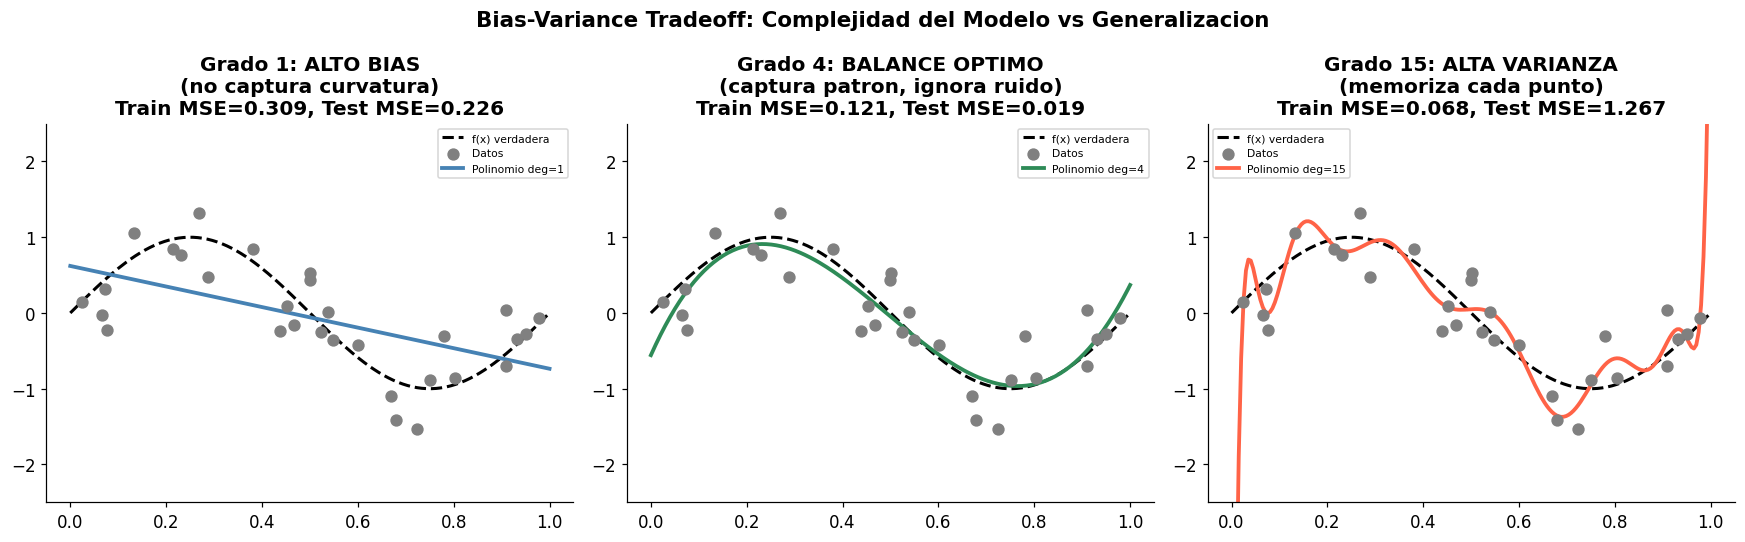

CLAVE: El MSE de train BAJA con complejidad, pero el MSE de test tiene un MINIMO.


In [33]:
# --- Bias-Variance: Demostracion con polinomios ---
np.random.seed(7)
n_pts = 30
x_true = np.linspace(0, 1, 200)
y_true = np.sin(2 * np.pi * x_true)
x_sample = np.sort(np.random.rand(n_pts))
y_sample = np.sin(2 * np.pi * x_sample) + np.random.normal(0, 0.3, n_pts)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
degrees = [1, 4, 15]
titles = ['Grado 1: ALTO BIAS\n(no captura curvatura)',
          'Grado 4: BALANCE OPTIMO\n(captura patron, ignora ruido)',
          'Grado 15: ALTA VARIANZA\n(memoriza cada punto)']
colors_bv = ['steelblue', 'seagreen', 'tomato']

for ax, deg, title, col in zip(axes, degrees, titles, colors_bv):
    coeffs = np.polyfit(x_sample, y_sample, deg)
    y_fit = np.polyval(coeffs, x_true)
    y_pred_s = np.polyval(coeffs, x_sample)
    tr_mse = mean_squared_error(y_sample, y_pred_s)
    # Estimate test MSE on true function
    te_mse = mean_squared_error(y_true, y_fit)
    ax.plot(x_true, y_true, 'k--', lw=2, label='f(x) verdadera')
    ax.scatter(x_sample, y_sample, s=50, color='gray', zorder=5, label='Datos')
    ax.plot(x_true, y_fit, color=col, lw=2.5, label=f'Polinomio deg={deg}')
    ax.set_title(f'{title}\nTrain MSE={tr_mse:.3f}, Test MSE={te_mse:.3f}', fontweight='bold')
    ax.legend(fontsize=7); ax.set_ylim(-2.5, 2.5)

plt.suptitle('Bias-Variance Tradeoff: Complejidad del Modelo vs Generalizacion',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print("CLAVE: El MSE de train BAJA con complejidad, pero el MSE de test tiene un MINIMO.")


---
# Bloque 3 — Model Selection y Validacion

### Train / Validation / Test Split
```
Datos (100%) → Train (60-70%) : fit parametros
             → Validation (15-20%) : seleccionar hiperparametros
             → Test (15-20%) : evaluacion FINAL (una sola vez)
```

### Data Leakage (SB&BD, Sec. 11.2.5)

> **Leakage** = informacion del test contamina el entrenamiento.
> **Pipeline de sklearn** garantiza que `fit()` solo usa train en cada fold de CV.

### Metricas de Evaluacion (ref: Padhmamuniraj, Medium)

| Metrica | Formula | Cuando | Rango |
|---------|---------|--------|-------|
| **Accuracy** | $(TP+TN)/N$ | Clases balanceadas | [0,1] |
| **Precision** | $TP/(TP+FP)$ | Minimizar FP | [0,1] |
| **Recall** | $TP/(TP+FN)$ | Minimizar FN | [0,1] |
| **F1-Score** | $2PR/(P+R)$ | Desbalanceo | [0,1] |
| **AUC-ROC** | Area bajo ROC | Ranking general | [0,1] |
| **Log-Loss** | $-\frac{1}{n}\sum[y\log p + (1-y)\log(1-p)]$ | Calibracion | $[0,\infty)$ |
| **Jaccard** | $|Y \cap \hat{Y}|/|Y \cup \hat{Y}|$ | Similitud conjuntos | [0,1] |


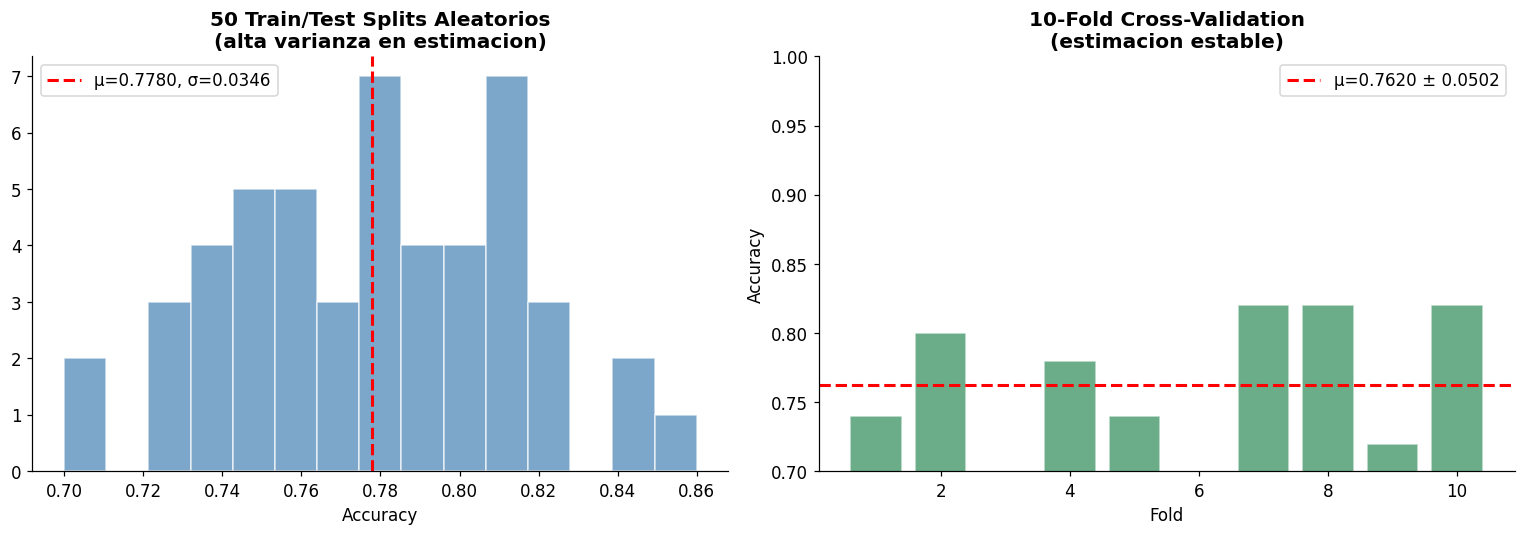

In [34]:
# --- Cross-Validation vs Single Split ---
X_demo, y_demo = make_classification(n_samples=500, n_features=20,
                                      n_informative=10, n_redundant=5,
                                      random_state=42, class_sep=0.8)

# METODO 1: 50 splits aleatorios
results_single = []
for seed in range(50):
    Xtr, Xte, ytr, yte = train_test_split(X_demo, y_demo, test_size=0.2, random_state=seed)
    pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    pipe.fit(Xtr, ytr)
    results_single.append(accuracy_score(yte, pipe.predict(Xte)))

# METODO 2: 10-Fold CV
pipe_cv = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
cv_scores_demo = cross_val_score(pipe_cv, X_demo, y_demo, cv=10, scoring='accuracy')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(results_single, bins=15, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].axvline(np.mean(results_single), color='red', lw=2, ls='--',
                label=f'μ={np.mean(results_single):.4f}, σ={np.std(results_single):.4f}')
axes[0].set_title('50 Train/Test Splits Aleatorios\n(alta varianza en estimacion)',
                   fontweight='bold')
axes[0].set_xlabel('Accuracy'); axes[0].legend()

axes[1].bar(range(1,11), cv_scores_demo, color='seagreen', alpha=0.7, edgecolor='white')
axes[1].axhline(cv_scores_demo.mean(), color='red', lw=2, ls='--',
                label=f'μ={cv_scores_demo.mean():.4f} ± {cv_scores_demo.std():.4f}')
axes[1].set_title('10-Fold Cross-Validation\n(estimacion estable)', fontweight='bold')
axes[1].set_xlabel('Fold'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].set_ylim(0.7, 1.0)
plt.tight_layout(); plt.show()


---
# Bloque 4 — Regresion Lineal y Gradient Descent (20 min)

## 4.1 Regresion Lineal — Teoria Completa

### Modelo (SB&BD, Cap. 9)
$$\hat{y} = \theta_0 + \theta_1 x_1 + \cdots + \theta_p x_p = \mathbf{X}\boldsymbol{\theta}$$

### Supuestos de Gauss-Markov (para que OLS sea BLUE)
1. **Linealidad:** $y = X\theta + \epsilon$
2. **Exogeneidad:** $\mathbb{E}[\epsilon|X] = 0$
3. **Homocedasticidad:** $\text{Var}(\epsilon|X) = \sigma^2 I$
4. **No autocorrelacion:** $\text{Cov}(\epsilon_i, \epsilon_j) = 0$
5. **No multicolinealidad perfecta:** $\text{rank}(X) = p+1$

### Funcion de Perdida — MSE
$$\mathcal{L}(\theta) = \frac{1}{n}\sum_{i=1}^n (y_i - \hat{y}_i)^2 = \frac{1}{n}\|y - X\theta\|^2$$

### Solucion Analitica — OLS
$$\hat{\theta}_{\text{OLS}} = (X^TX)^{-1}X^Ty$$

### Parametros vs Hiperparametros

| Elemento | Tipo | Descripcion |
|----------|------|-------------|
| $\theta_0,...,\theta_p$ | **Parametros** | Coeficientes aprendidos por OLS/GD |
| Regularizacion $\lambda$ | **Hiperparametro** | Fuerza de penalizacion (Ridge/Lasso) |
| Learning rate $\alpha$ | **Hiperparametro** | Paso de GD |

### Metricas
- **MSE** = $\frac{1}{n}\sum(y-\hat{y})^2$, **RMSE** = $\sqrt{\text{MSE}}$
- **MAE** = $\frac{1}{n}\sum|y-\hat{y}|$ (robusto a outliers)
- **R²** = $1 - \frac{\text{SS}_{res}}{\text{SS}_{tot}}$ (varianza explicada)

## 4.2 Gradient Descent (SB&BD, Cap. 14)

$$\theta^{(t+1)} = \theta^{(t)} - \alpha \nabla_\theta \mathcal{L}(\theta^{(t)})$$

Para MSE: $\nabla_\theta \mathcal{L} = -\frac{2}{n}X^T(y - X\theta)$

### Convergencia (Teorema 14.1, SB&BD)
Para funciones convexas y $\rho$-Lipschitz sobre conjunto acotado $B$:
$$\mathcal{L}(\bar{\theta}) - \min_\theta \mathcal{L}(\theta) \leq \frac{\rho B}{\sqrt{T}}$$

despues de $T$ iteraciones con step size $\alpha = \frac{B}{\rho\sqrt{T}}$.

### Variantes
| Variante | Batch | Velocidad | Estabilidad |
|----------|-------|-----------|-------------|
| **Batch GD** | Todo $S$ | Lento | Alta |
| **SGD** | 1 ejemplo | Rapido | Baja (ruidoso) |
| **Mini-batch** | $b$ ejemplos | Balance | Balance |
| **Adam** | Adaptativo | Rapido | Alta |


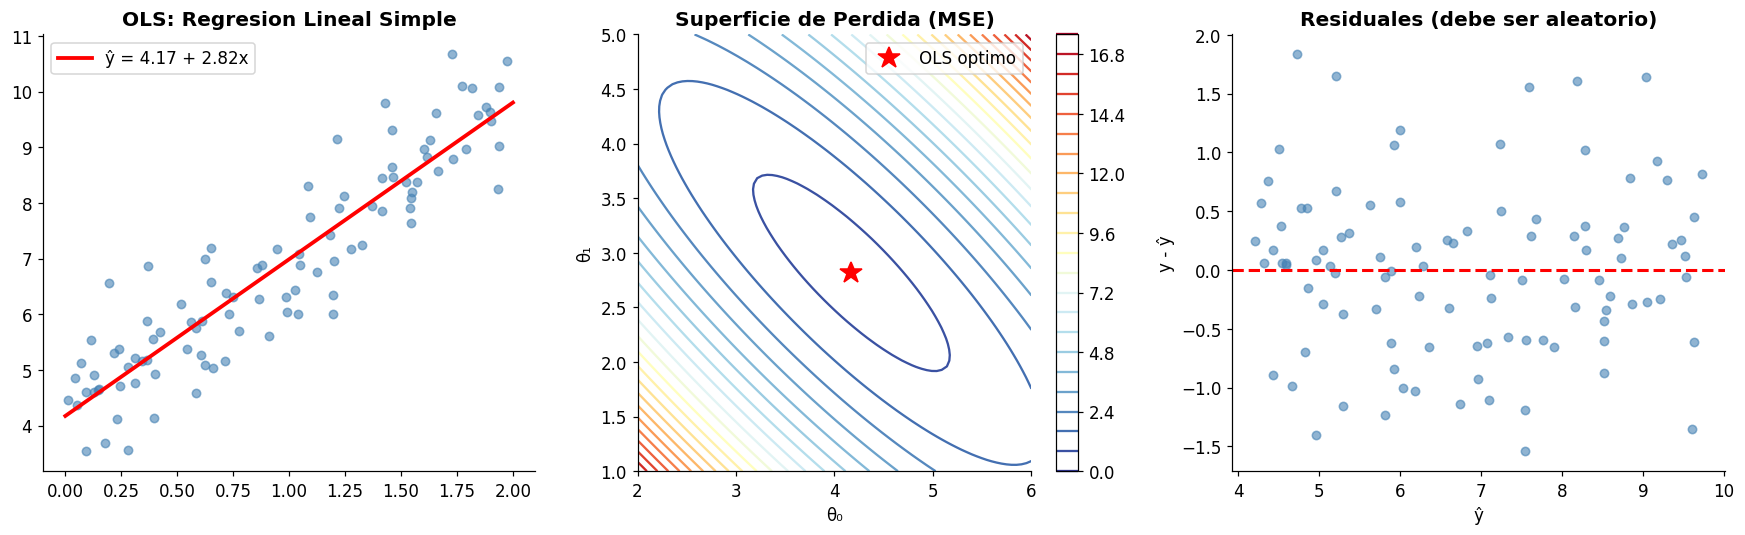

R² = 0.8434, RMSE = 0.7185


In [35]:
# --- 4.1 Regresion Lineal + Superficie de Loss ---
np.random.seed(42)
n_reg = 100
X_reg = 2 * np.random.rand(n_reg, 1)
y_reg = 4 + 3 * X_reg.flatten() + np.random.randn(n_reg) * 0.8

lr = LinearRegression().fit(X_reg, y_reg)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Scatter + fit
axes[0].scatter(X_reg, y_reg, alpha=0.6, s=30, color='steelblue')
x_line = np.linspace(0, 2, 100).reshape(-1,1)
axes[0].plot(x_line, lr.predict(x_line), 'r-', lw=2.5,
             label=f'ŷ = {lr.intercept_:.2f} + {lr.coef_[0]:.2f}x')
axes[0].set_title('OLS: Regresion Lineal Simple', fontweight='bold')
axes[0].legend()

# 2. Loss surface
t0r = np.linspace(2, 6, 80); t1r = np.linspace(1, 5, 80)
T0, T1 = np.meshgrid(t0r, t1r)
MSE_surf = np.array([[np.mean((y_reg - (t0+t1*X_reg.flatten()))**2)
                       for t0 in t0r] for t1 in t1r])
cs = axes[1].contour(T0, T1, MSE_surf, levels=20, cmap='RdYlBu_r')
axes[1].plot(lr.intercept_, lr.coef_[0], 'r*', ms=15, label='OLS optimo')
axes[1].set_xlabel('θ₀'); axes[1].set_ylabel('θ₁')
axes[1].set_title('Superficie de Perdida (MSE)', fontweight='bold')
axes[1].legend(); plt.colorbar(cs, ax=axes[1])

# 3. Residuales
y_pred_reg = lr.predict(X_reg)
axes[2].scatter(y_pred_reg, y_reg - y_pred_reg, alpha=0.6, s=30, color='steelblue')
axes[2].axhline(0, color='red', lw=2, ls='--')
axes[2].set_title('Residuales (debe ser aleatorio)', fontweight='bold')
axes[2].set_xlabel('ŷ'); axes[2].set_ylabel('y - ŷ')

plt.tight_layout(); plt.show()
print(f"R² = {r2_score(y_reg, y_pred_reg):.4f}, RMSE = {np.sqrt(mean_squared_error(y_reg, y_pred_reg)):.4f}")


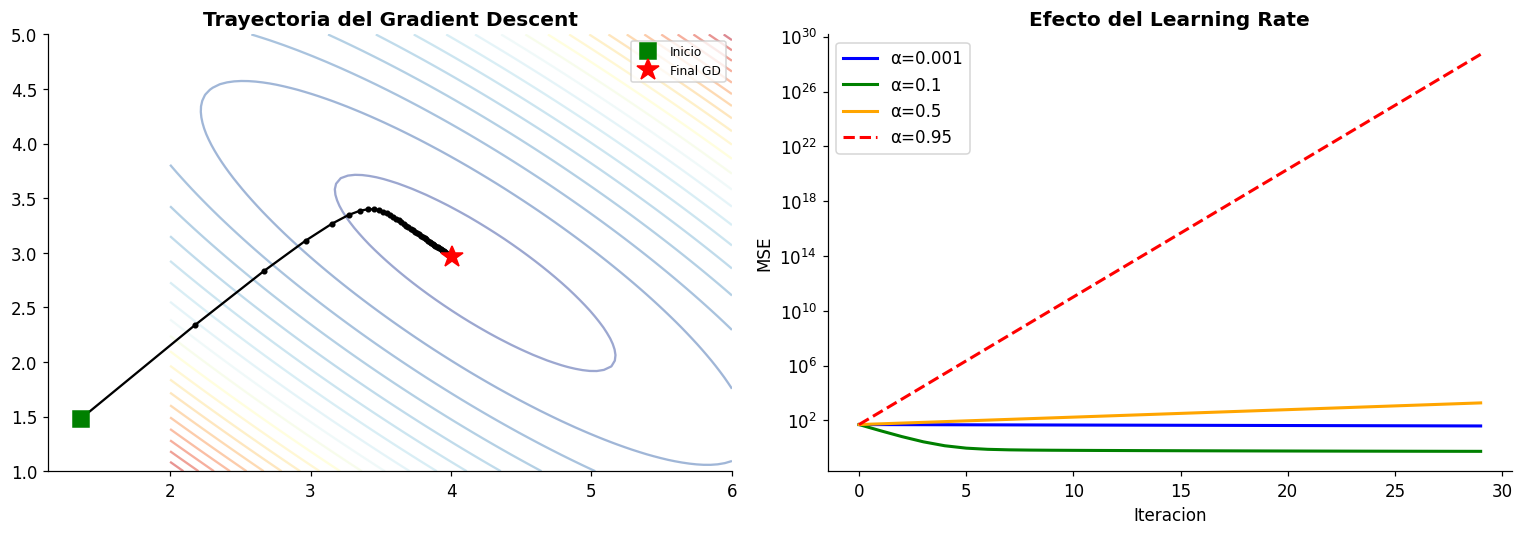

GD: θ₀=4.0036, θ₁=2.9649 | OLS: θ₀=4.1721, θ₁=2.8161


In [36]:
# --- 4.2 Gradient Descent desde cero ---
X_aug = np.c_[np.ones(n_reg), X_reg.flatten()]
theta_gd = np.array([0.0, 0.0])
alpha = 0.1; n_iters = 50

history = {'t0':[], 't1':[], 'loss':[]}
for i in range(n_iters):
    y_hat = X_aug @ theta_gd
    loss = np.mean((y_reg - y_hat)**2)
    grad = -2/n_reg * X_aug.T @ (y_reg - y_hat)
    theta_gd -= alpha * grad
    history['t0'].append(theta_gd[0]); history['t1'].append(theta_gd[1])
    history['loss'].append(loss)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trayectoria
cs2 = axes[0].contour(T0, T1, MSE_surf, levels=20, cmap='RdYlBu_r', alpha=0.5)
axes[0].plot(history['t0'], history['t1'], 'ko-', ms=3, lw=1.5)
axes[0].plot(history['t0'][0], history['t1'][0], 'gs', ms=10, label='Inicio')
axes[0].plot(history['t0'][-1], history['t1'][-1], 'r*', ms=15, label='Final GD')
axes[0].set_title('Trayectoria del Gradient Descent', fontweight='bold')
axes[0].legend(fontsize=8)

# Learning rates comparados
for a, c, ls in [(0.001,'blue','-'),(0.1,'green','-'),(0.5,'orange','-'),(0.95,'red','--')]:
    th=np.array([0.,0.]); losses=[]
    for _ in range(50):
        yh = X_aug@th; l=np.mean((y_reg-yh)**2)
        g=-2/n_reg*X_aug.T@(y_reg-yh); th -= a*g; losses.append(l)
    axes[1].plot(losses[:30], color=c, lw=2, ls=ls, label=f'α={a}')
axes[1].set_xlabel('Iteracion'); axes[1].set_ylabel('MSE')
axes[1].set_title('Efecto del Learning Rate', fontweight='bold')
axes[1].legend(); axes[1].set_yscale('log')
plt.tight_layout(); plt.show()
print(f"GD: θ₀={theta_gd[0]:.4f}, θ₁={theta_gd[1]:.4f} | OLS: θ₀={lr.intercept_:.4f}, θ₁={lr.coef_[0]:.4f}")


---
# Bloque 5 — Arboles de Decision

## Fundamento Teorico (SB&BD, Cap. 18)

### Definicion Formal
Un arbol de decision es un predictor $h: \mathcal{X} \to \mathcal{Y}$ que recorre un camino
de la raiz a una hoja. En cada nodo interno, se elige el hijo sucesor
segun una **regla de particion** (splitting rule).

### Metricas de Impureza — Gain Measures (SB&BD, Sec. 18.2.1)

Para un nodo con proporcion de clase positiva $p$:

| Metrica | $C(p)$ | Usado por |
|---------|--------|-----------|
| **Error de clasificacion** | $\min(p, 1-p)$ | Basico |
| **Gini Index** | $2p(1-p)$ | CART (Breiman et al., 1984) |
| **Entropia** | $-p\log_2(p) - (1-p)\log_2(1-p)$ | ID3, C4.5 (Quinlan, 1993) |

La **ganancia** de particionar en feature $i$:

$$\text{Gain}(S, i) = C(\hat{P}_S[y=1]) - \left[\hat{P}_S[x_i=1] \cdot C(\hat{P}_S[y=1|x_i=1]) + \hat{P}_S[x_i=0] \cdot C(\hat{P}_S[y=1|x_i=0])\right]$$

### Algoritmo ID3 (SB&BD, Sec. 18.2)
```
ID3(S, A):
  Si todos los labels en S son 1 → return hoja(1)
  Si todos son 0 → return hoja(0)
  Si A = ∅ → return hoja(mayoria)
  j = argmax_{i∈A} Gain(S, i)
  T₁ = ID3({(x,y)∈S : xⱼ=1}, A\{j})
  T₂ = ID3({(x,y)∈S : xⱼ=0}, A\{j})
  return Nodo(xⱼ?, T₁, T₂)
```

### Parametros e Hiperparametros

| Elemento | Tipo | Efecto |
|----------|------|--------|
| Reglas de split | **Parametro** (aprendido) | Particiona el espacio |
| Labels en hojas | **Parametro** | Prediccion de cada region |
| `max_depth` | **Hiperparametro** | Profundidad maxima (controla varianza) |
| `min_samples_leaf` | **Hiperparametro** | Min obs por hoja (regulariza) |
| `min_samples_split` | **Hiperparametro** | Min obs para dividir |
| `criterion` | **Hiperparametro** | gini vs entropy |
| `max_features` | **Hiperparametro** | Features consideradas por split |

### Funcion de Perdida
No minimiza una loss explicita globalmente (es un algoritmo **greedy**).
Localmente minimiza la impureza en cada nodo.

### Bound MDL (SB&BD, Thm 18.1)
Para un arbol con $n$ nodos, con probabilidad $\geq 1-\delta$:
$$L_\mathcal{D}(h) \leq L_S(h) + \sqrt{\frac{(n+1)\log_2(d+3) + \log(2/\delta)}{2m}}$$

### Pruning (SB&BD, Sec. 18.2.2)
Bottom-up: reemplazar nodos por hojas si reduce el bound estimado de $L_\mathcal{D}$.

### Random Forests (SB&BD, Sec. 18.3; Breiman, 2001)
Ensemble de arboles donde cada arbol usa:
1. **Bootstrap sample** de $S$
2. **Subset aleatorio** de features en cada split
→ **Decorrelaciona** arboles → mejor reduccion de varianza.

### Pregunta Clase
> *¿Por que los arboles de decision NO necesitan escalado de features?*
> **R:** Porque los splits son de la forma $x_i < \theta$ (comparaciones de orden), no usan distancias.


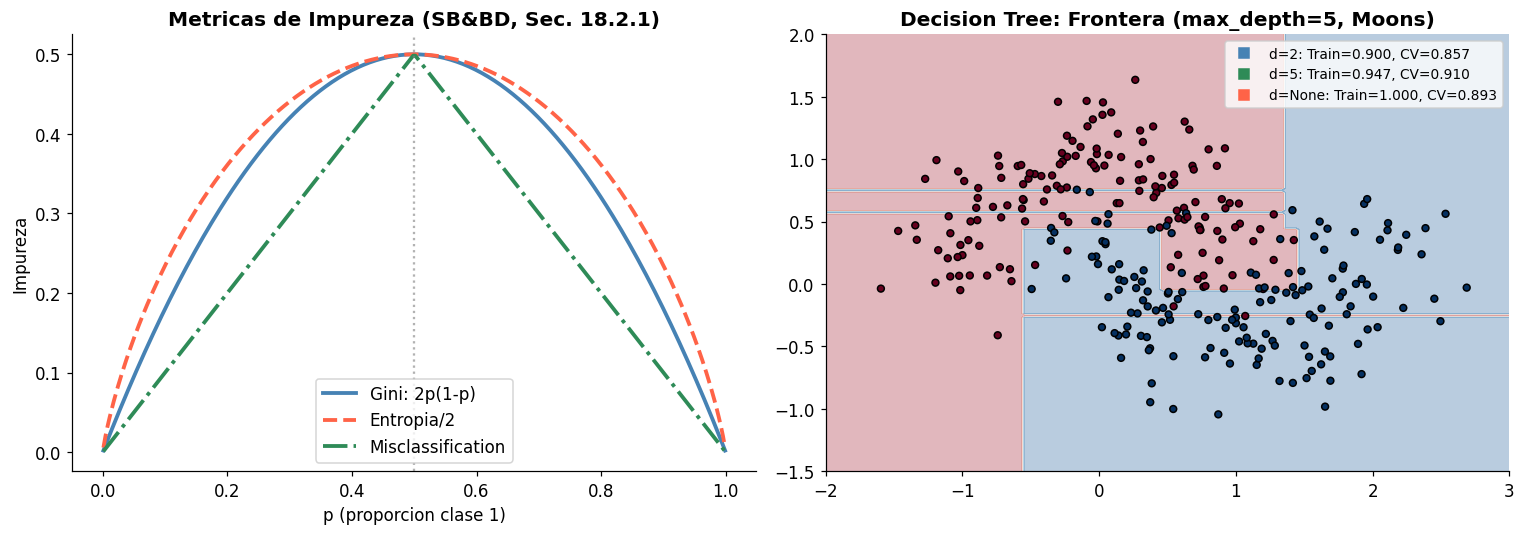

In [37]:
# --- Arboles: Impureza, fronteras, y efecto de max_depth ---
# 1. Metricas de impureza
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
p = np.linspace(0.001, 0.999, 300)
gini = 1 - p**2 - (1-p)**2
entropy = -(p*np.log2(p) + (1-p)*np.log2(1-p))
mc_err = np.minimum(p, 1-p)

axes[0].plot(p, gini, lw=2.5, label='Gini: 2p(1-p)', color='steelblue')
axes[0].plot(p, entropy/2, lw=2.5, ls='--', label='Entropia/2', color='tomato')
axes[0].plot(p, mc_err, lw=2.5, ls='-.', label='Misclassification', color='seagreen')
axes[0].axvline(0.5, ls=':', color='gray', alpha=0.6)
axes[0].set_xlabel('p (proporcion clase 1)'); axes[0].set_ylabel('Impureza')
axes[0].set_title('Metricas de Impureza (SB&BD, Sec. 18.2.1)', fontweight='bold')
axes[0].legend()

# 2. Fronteras de decision: efecto de depth
X_moons, y_moons = make_moons(n_samples=300, noise=0.25, random_state=42)
depths = [2, 5, None]
for d, col in zip(depths, ['steelblue','seagreen','tomato']):
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_moons, y_moons)
    cv_d = cross_val_score(dt, X_moons, y_moons, cv=5).mean()
    tr_d = accuracy_score(y_moons, dt.predict(X_moons))
    axes[1].plot([], [], 's', color=col, label=f'd={d}: Train={tr_d:.3f}, CV={cv_d:.3f}')

# Plot best depth boundary
dt_best = DecisionTreeClassifier(max_depth=5, random_state=42).fit(X_moons, y_moons)
xx,yy = np.meshgrid(np.linspace(-2,3,200), np.linspace(-1.5,2,200))
Z = dt_best.predict(np.c_[xx.ravel(),yy.ravel()]).reshape(xx.shape)
axes[1].contourf(xx,yy,Z,alpha=0.3,cmap='RdBu')
axes[1].scatter(X_moons[:,0],X_moons[:,1],c=y_moons,cmap='RdBu',edgecolors='k',s=20)
axes[1].set_title('Decision Tree: Frontera (max_depth=5, Moons)', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout(); plt.show()


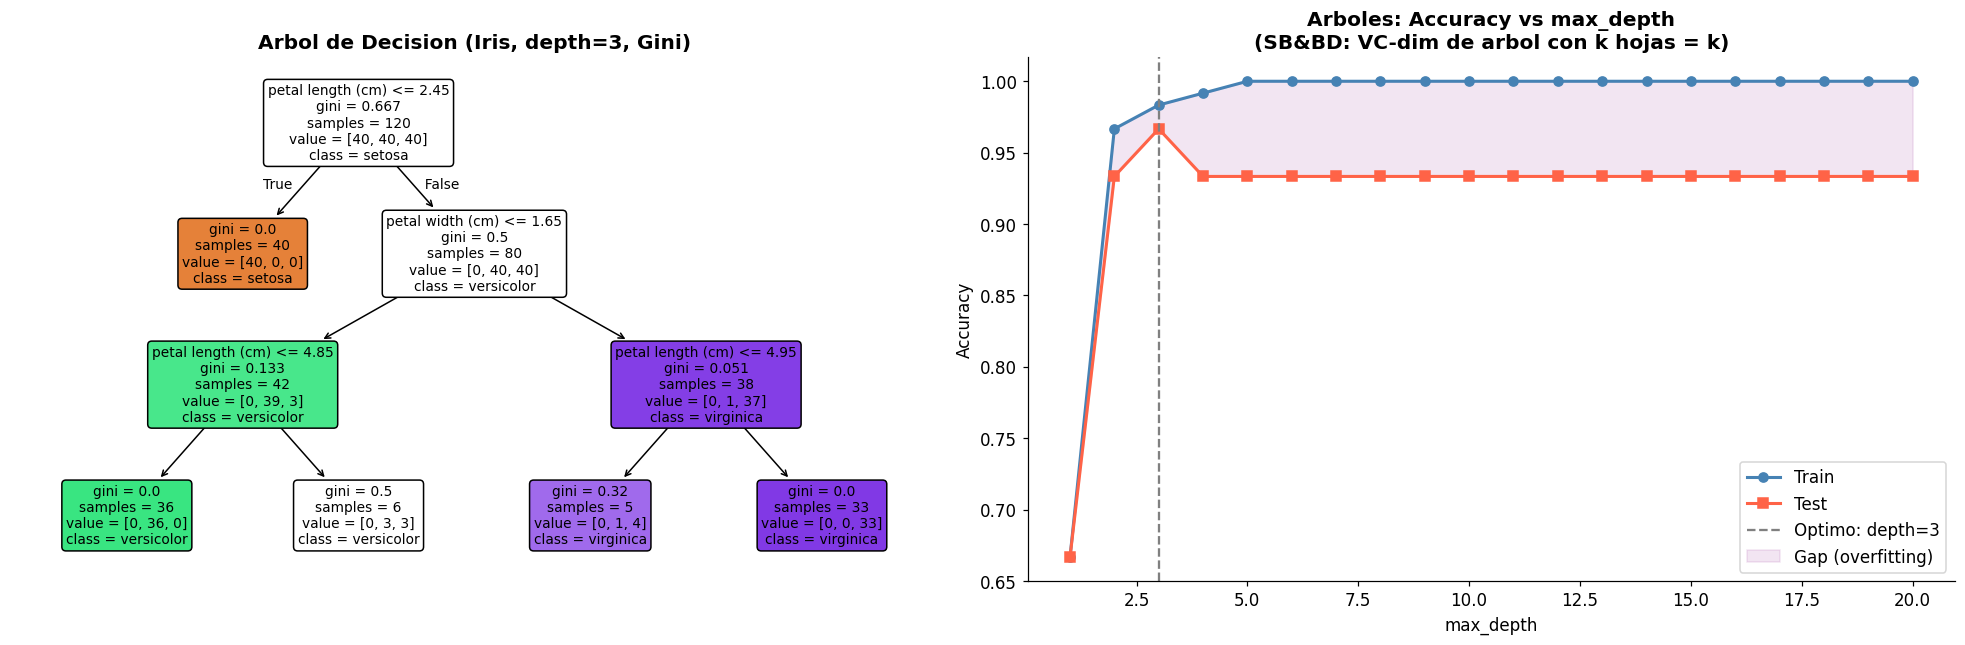

REGLAS DEL ARBOL (interpretables para negocio):
|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.65
|   |   |--- petal length (cm) <= 4.85
|   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.85
|   |   |   |--- class: 1
|   |--- petal width (cm) >  1.65
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: 2
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- class: 2


Test Accuracy: 0.9333
Nodes: 9, Depth: 3


In [38]:
# --- Arbol completo: visualizacion + reglas + learning curve ---
from sklearn.datasets import load_iris
iris_full = load_iris()
X_ir, y_ir = iris_full.data, iris_full.target
X_tr_ir, X_te_ir, y_tr_ir, y_te_ir = train_test_split(X_ir, y_ir, test_size=0.2,
                                                         random_state=42, stratify=y_ir)
# Entrenar arbol interpretable
dt_iris = DecisionTreeClassifier(max_depth=3, min_samples_leaf=5,
                                  criterion='gini', random_state=42)
dt_iris.fit(X_tr_ir, y_tr_ir)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Visualizar arbol
sktree.plot_tree(dt_iris, feature_names=iris_full.feature_names,
                 class_names=iris_full.target_names,
                 filled=True, rounded=True, fontsize=9, ax=axes[0])
axes[0].set_title('Arbol de Decision (Iris, depth=3, Gini)', fontweight='bold')

# Learning curve: depth vs accuracy
depths_range = range(1, 21)
tr_scores_dt, te_scores_dt = [], []
for d in depths_range:
    dt_d = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt_d.fit(X_tr_ir, y_tr_ir)
    tr_scores_dt.append(accuracy_score(y_tr_ir, dt_d.predict(X_tr_ir)))
    te_scores_dt.append(accuracy_score(y_te_ir, dt_d.predict(X_te_ir)))

best_d = list(depths_range)[np.argmax(te_scores_dt)]
axes[1].plot(depths_range, tr_scores_dt, 'o-', color='steelblue', lw=2, label='Train')
axes[1].plot(depths_range, te_scores_dt, 's-', color='tomato', lw=2, label='Test')
axes[1].axvline(best_d, color='gray', ls='--', label=f'Optimo: depth={best_d}')
axes[1].fill_between(depths_range,
    [min(a,b) for a,b in zip(tr_scores_dt, te_scores_dt)],
    [max(a,b) for a,b in zip(tr_scores_dt, te_scores_dt)],
    alpha=0.1, color='purple', label='Gap (overfitting)')
axes[1].set_xlabel('max_depth'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Arboles: Accuracy vs max_depth\n(SB&BD: VC-dim de arbol con k hojas = k)',
                   fontweight='bold')
axes[1].legend()
plt.tight_layout(); plt.show()

# Reglas en texto
rules = export_text(dt_iris, feature_names=iris_full.feature_names, max_depth=3)
print("REGLAS DEL ARBOL (interpretables para negocio):")
print(rules[:800])
print(f"\nTest Accuracy: {accuracy_score(y_te_ir, dt_iris.predict(X_te_ir)):.4f}")
print(f"Nodes: {dt_iris.tree_.node_count}, Depth: {dt_iris.get_depth()}")


---
# Bloque 7 — Series de Tiempo y Cadenas de Markov (15 min)

## Cadenas de Markov — Fundamento

### Propiedad de Markov (sin memoria)
$$P(X_{t+1} = s_j \mid X_t=s_i, X_{t-1},...) = P(X_{t+1}=s_j \mid X_t=s_i) = p_{ij}$$

### Matriz de Transicion
$\mathbf{P}$ donde $\sum_j p_{ij} = 1$ para todo $i$.

### Distribucion Estacionaria
$\pi$ tal que $\pi = \pi\mathbf{P}$ (eigenvector izquierdo con eigenvalue 1).

### Conexion con NLP
Un modelo de lenguaje **n-grama** es una Cadena de Markov de orden $n-1$:
$$P(w_t | w_{t-1}, w_{t-2},...,w_{t-n+1})$$

> Los LLMs modernos (GPT, LLaMA) generalizan esto con Transformers de **contexto completo**
> en lugar de ventanas fijas de n palabras.


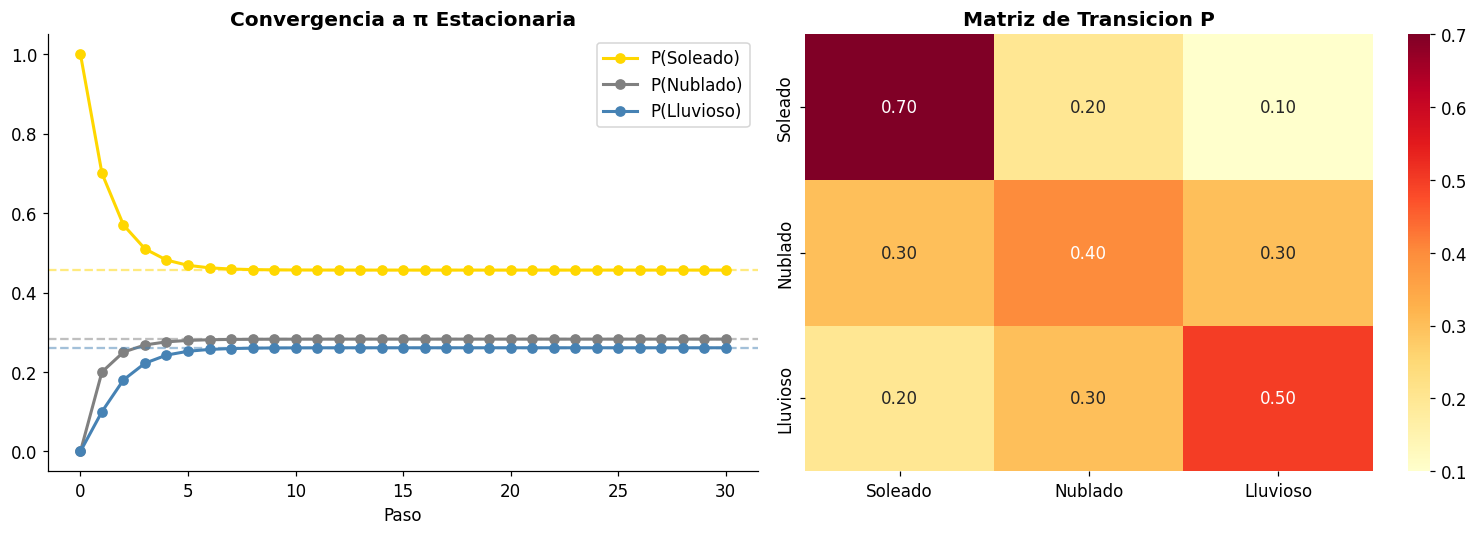


MODELO DE LENGUAJE BIGRAMA (Cadena de Markov de orden 1)
Probabilidades: 'el' → {'gato': 0.38, 'perro': 0.38, 'parque': 0.25}
  1. el parque . el gato duerme en la casa . el gato come
  2. el perro corre . el gato come en el parque . el gato
  3. el gato come pescado . el parque . el perro corre . el
  4. el perro come pescado . el parque . la casa es verde .
  5. el parque . el gato come en la casa . la casa .

>> GPT = Esta misma idea, pero con Transformers de miles de millones de parametros


In [25]:
# --- Cadena de Markov: Clima + Generador de Texto ---
np.random.seed(42)
states = ['Soleado','Nublado','Lluvioso']
P = np.array([[0.7,0.2,0.1],[0.3,0.4,0.3],[0.2,0.3,0.5]])

# Simular
n_steps = 200
hist = [0]
for _ in range(n_steps-1):
    hist.append(np.random.choice(3, p=P[hist[-1]]))

# Distribucion estacionaria
evals, evecs = np.linalg.eig(P.T)
pi = np.real(evecs[:, np.argmin(np.abs(evals-1))])
pi /= pi.sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Convergencia
pi_t = np.array([1,0,0], dtype=float)
conv = [pi_t.copy()]
for _ in range(30):
    pi_t = pi_t @ P; conv.append(pi_t.copy())
conv = np.array(conv)
for i,(s,c) in enumerate(zip(states, ['gold','gray','steelblue'])):
    axes[0].plot(conv[:,i], 'o-', color=c, lw=2, label=f'P({s})')
    axes[0].axhline(pi[i], color=c, ls='--', alpha=0.5)
axes[0].set_title('Convergencia a π Estacionaria', fontweight='bold')
axes[0].legend(); axes[0].set_xlabel('Paso')

# Heatmap
sns.heatmap(P, annot=True, fmt='.2f', cmap='YlOrRd', xticklabels=states,
            yticklabels=states, ax=axes[1])
axes[1].set_title('Matriz de Transicion P', fontweight='bold')
plt.tight_layout(); plt.show()

# Generador de texto bigrama
corpus = "el gato come pescado. el perro come carne. el gato duerme. el perro corre. la casa es grande. el parque es verde. el gato come en la casa. el perro duerme en el parque."
words = corpus.lower().replace('.', ' .').split()
bigram = {}
for i in range(len(words)-1):
    w = words[i]
    if w not in bigram: bigram[w] = {}
    bigram[w][words[i+1]] = bigram[w].get(words[i+1], 0) + 1
for w in bigram:
    total = sum(bigram[w].values())
    for nw in bigram[w]: bigram[w][nw] /= total

print("\nMODELO DE LENGUAJE BIGRAMA (Cadena de Markov de orden 1)")
print("Probabilidades: 'el' →", {k:round(v,2) for k,v in bigram.get('el',{}).items()})
for i in range(5):
    cur = 'el'; sent = [cur]
    for _ in range(12):
        if cur not in bigram: break
        nws = list(bigram[cur].keys()); ps = list(bigram[cur].values())
        cur = np.random.choice(nws, p=ps); sent.append(cur)
    print(f"  {i+1}. {' '.join(sent)}")
print("\n>> GPT = Esta misma idea, pero con Transformers de miles de millones de parametros")


---
# Bloque 8 — NLP: Tokenizacion, Representaciones y Semantica (20 min)

> NLP permite a las maquinas **entender, interpretar y generar** lenguaje humano.
> Opera "invisiblemente" detras de: buscadores, asistentes virtuales, filtros de spam,
> sistemas de recomendacion, chatbots, y traductores automaticos.

## Pipeline Clasico
```
Texto crudo → Limpieza → Tokenizacion → Normalizacion → Vectorizacion → Modelo → Prediccion
```

### Tokenizacion
Separar texto en **tokens** (palabras, subpalabras, caracteres).
- `str.split()` → basico pero pierde puntuacion
- **Regex** `re.findall(r'\w+', text)` → mejor
- **NLTK** `word_tokenize()` → maneja contracciones, puntuacion
- **spaCy** → tokenizacion + POS + NER integrados

### Normalizacion
- **Stemming** (NLTK SnowballStemmer): cortar sufijos → rapido, impreciso
- **Lematizacion** (spaCy): forma canonica via diccionario → preciso, lento
- **Stop Words**: remover "el", "de", "la" (sin contenido semantico)

### Distancia de Edicion (Levenshtein)
$$L = S + D + I \quad \text{(sustituciones + eliminaciones + inserciones)}$$

### Representaciones Vectoriales

| Metodo | Formula | Captura Orden? | Semantica? |
|--------|---------|---------------|------------|
| **Bag of Words** | Conteo de tokens | No | No |
| **TF-IDF** | $\text{TF}(t,d) \times \log\frac{N}{\text{df}(t)}$ | No | Parcial (IDF) |
| **Word2Vec** | Neural embeddings | Ventana local | Si |
| **BERT** | Transformer bidireccional | Contexto completo | Si |

### Semantica (ref: Wang, Towards Data Science)

La **semantica** es el significado. Los metodos clasicos (BoW, TF-IDF) NO capturan semantica:
- "contento" y "feliz" son vectores **ortogonales** en BoW
- Los **word embeddings** (Word2Vec, GloVe) colocan sinonimos cerca en el espacio vectorial
- **Transformers** (BERT, GPT) capturan semantica **contextual**: "banco" (financiero vs rio)

### Aplicaciones del NLP en el Mundo Real
1. **Sentiment Analysis** — reviews, redes sociales, encuestas
2. **Chatbots y Asistentes** — Siri, Alexa, ChatGPT
3. **Traduccion Automatica** — Google Translate, DeepL
4. **Deteccion de Spam** — Gmail, Outlook
5. **Resumen Automatico** — noticias, papers
6. **NER (Named Entity Recognition)** — extraccion de entidades (personas, lugares)


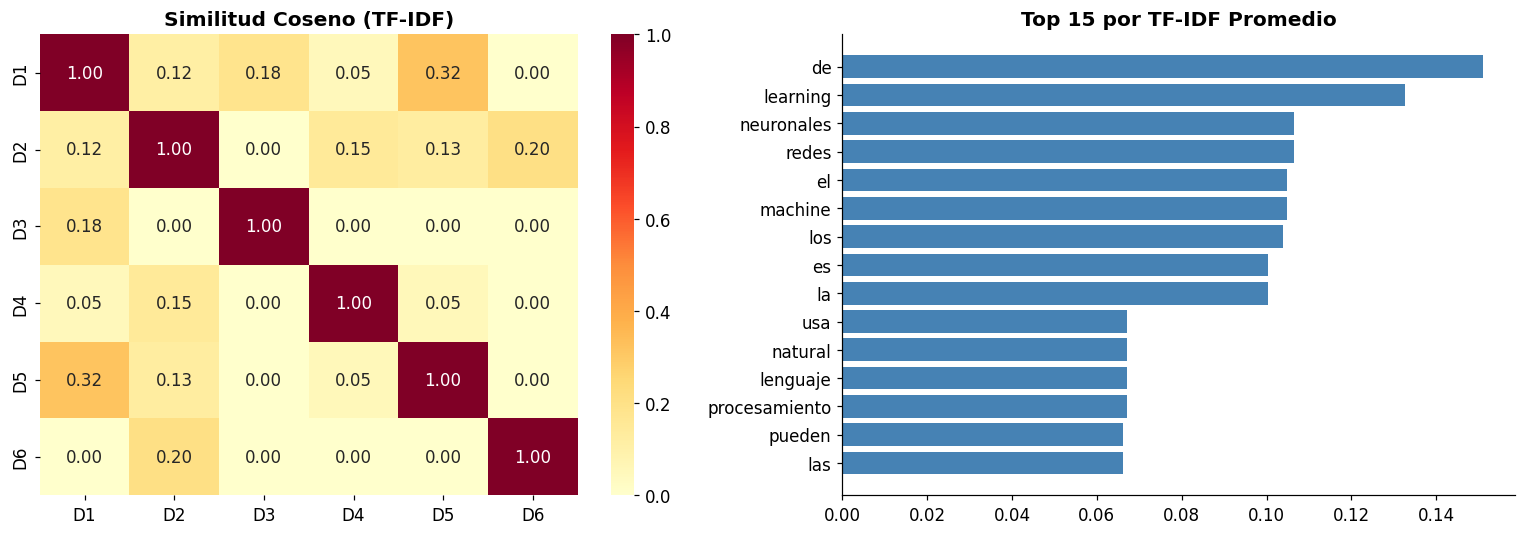

Vocabulario: 38 tokens
Dimension de cada doc: 38
D1 (ML/IA) vs D5 (NLP/ML) similitud = 0.319 (alta)
D1 (ML/IA) vs D3 (Reg. Lineal) similitud = 0.181 (baja)


In [26]:
# --- NLP: BoW, TF-IDF, Similitud Coseno ---
corpus = [
    "el machine learning es una rama de la inteligencia artificial",
    "los algoritmos de deep learning usan redes neuronales profundas",
    "la regresion lineal es un modelo parametrico clasico",
    "los arboles de decision son modelos no parametricos",
    "el procesamiento de lenguaje natural usa machine learning",
    "las redes neuronales pueden aprender representaciones semanticas",
]

bow_vec = CountVectorizer()
X_bow = bow_vec.fit_transform(corpus)
tfidf_vec = TfidfVectorizer()
X_tfidf = tfidf_vec.fit_transform(corpus)

from sklearn.metrics.pairwise import cosine_similarity
sim = cosine_similarity(X_tfidf)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(sim, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=[f'D{i+1}' for i in range(6)],
            yticklabels=[f'D{i+1}' for i in range(6)], ax=axes[0])
axes[0].set_title('Similitud Coseno (TF-IDF)', fontweight='bold')

mean_tfidf = X_tfidf.mean(axis=0).A1
top_idx = np.argsort(mean_tfidf)[-15:]
words_arr = np.array(tfidf_vec.get_feature_names_out())
axes[1].barh(words_arr[top_idx], mean_tfidf[top_idx], color='steelblue')
axes[1].set_title('Top 15 por TF-IDF Promedio', fontweight='bold')
plt.tight_layout(); plt.show()
print(f"Vocabulario: {len(bow_vec.get_feature_names_out())} tokens")
print(f"Dimension de cada doc: {X_bow.shape[1]}")
print(f"D1 (ML/IA) vs D5 (NLP/ML) similitud = {sim[0,4]:.3f} (alta)")
print(f"D1 (ML/IA) vs D3 (Reg. Lineal) similitud = {sim[0,2]:.3f} (baja)")


---
# Bloque 9 — Pipeline NLP Completo: Sentiment Analysis (20 min)

## Naive Bayes Multinomial

$$P(y|x_1,...,x_n) \propto P(y)\prod_{i=1}^n P(x_i|y)$$

### Parametros
- $P(y)$: **prior** (frecuencia de cada clase)
- $P(x_i|y)$: **likelihood** (frecuencia de cada token por clase, con suavizado Laplace $\alpha$)

### Hiperparametros
| Param | Valores | Efecto |
|-------|---------|--------|
| $\alpha$ | 0.01 - 10 | Suavizado Laplace (evita P=0) |
| `fit_prior` | True/False | Usar priors de los datos |

### Loss Function
Maximiza la **log-verosimilitud** (equivale a minimizar cross-entropy):
$$\mathcal{L} = -\sum_{i=1}^n \left[y_i\log P(y_i|x_i) + (1-y_i)\log(1-P(y_i|x_i))\right]$$

### VADER (Valence Aware Dictionary and sEntiment Reasoner)
Analizador basado en **lexico** (sin entrenamiento). Asigna scores con un diccionario de valencias.


In [27]:
# --- Sentiment Analysis: Pipeline completo ---
np.random.seed(42)
import random; random.seed(42)

pos = ["I love this product amazing works great", "Best purchase ever happy quality",
       "Excellent service highly recommend", "Fantastic movie loved every minute",
       "Great experience definitely come back", "Delicious food wonderful atmosphere",
       "Really impressed works well thank you", "Grateful opportunity changed life",
       "Beautiful design perfect functionality", "Outstanding exceeded expectations"] * 20
neg = ["Terrible product broke waste money", "Worst experience never coming back",
       "Horrible service ignored complaint", "Awful movie boring predictable",
       "Very disappointed quality not worth", "Food cold service slow rude",
       "Does not work scam avoid", "Regret buying total waste not recommend",
       "Poor design falls apart cheaply made", "Frustrating nothing worked expected"] * 20

def add_var(texts):
    out = []
    for t in texts:
        w = t.split()
        if random.random() > 0.5: w = w[:-random.randint(1, min(3,len(w)-2))]
        out.append(' '.join(w))
    return out

tweets_df = pd.DataFrame({
    'text': add_var(pos) + add_var(neg),
    'sentiment': [1]*len(pos) + [0]*len(neg)
}).sample(frac=1, random_state=42).reset_index(drop=True)

tweets_df['text_clean'] = tweets_df['text'].apply(
    lambda t: re.sub(r'\s+',' ', re.sub(r'[^a-z\s]','', str(t).lower())).strip())

X_tw = tweets_df['text_clean']; y_tw = tweets_df['sentiment']
X_tr, X_te, y_tr, y_te = train_test_split(X_tw, y_tw, test_size=0.2,
                                            random_state=42, stratify=y_tw)

# Comparacion
vecs = {
    'BoW (1g)': CountVectorizer(max_features=2000, stop_words='english'),
    'BoW (1-2g)': CountVectorizer(max_features=2000, ngram_range=(1,2), stop_words='english'),
    'TF-IDF (1-2g)': TfidfVectorizer(max_features=2000, ngram_range=(1,2),
                                      stop_words='english', sublinear_tf=True),
}
clfs = {'NaiveBayes': MultinomialNB(alpha=0.5),
        'LogReg': LogisticRegression(max_iter=1000, C=1.0, random_state=42)}

print(f"Dataset: {len(tweets_df)} docs ({y_tw.mean():.1%} positivos)")
print("=" * 65)
print(f"  {'Vec':<18} {'Clf':<12} {'F1':>6} {'AUC':>7} {'Acc':>7}")
print("=" * 65)
best_f1 = 0; best_cfg = ""
for vn, v in vecs.items():
    Xtr_v=v.fit_transform(X_tr); Xte_v=v.transform(X_te)
    for cn, c in clfs.items():
        c.fit(Xtr_v, y_tr)
        yp=c.predict(Xte_v); ypr=c.predict_proba(Xte_v)[:,1]
        f1=f1_score(y_te,yp); au=auc(*roc_curve(y_te,ypr)[:2]); ac=accuracy_score(y_te,yp)
        print(f"  {vn:<18} {cn:<12} {f1:>6.4f} {au:>7.4f} {ac:>7.4f}")
        if f1>best_f1: best_f1=f1; best_cfg=f"{vn}+{cn}"
print(f"\nMejor: {best_cfg} (F1={best_f1:.4f})")


Dataset: 400 docs (50.0% positivos)
  Vec                Clf              F1     AUC     Acc
  BoW (1g)           NaiveBayes   1.0000  1.0000  1.0000
  BoW (1g)           LogReg       1.0000  1.0000  1.0000
  BoW (1-2g)         NaiveBayes   1.0000  1.0000  1.0000
  BoW (1-2g)         LogReg       1.0000  1.0000  1.0000
  TF-IDF (1-2g)      NaiveBayes   1.0000  1.0000  1.0000
  TF-IDF (1-2g)      LogReg       1.0000  1.0000  1.0000

Mejor: BoW (1g)+NaiveBayes (F1=1.0000)


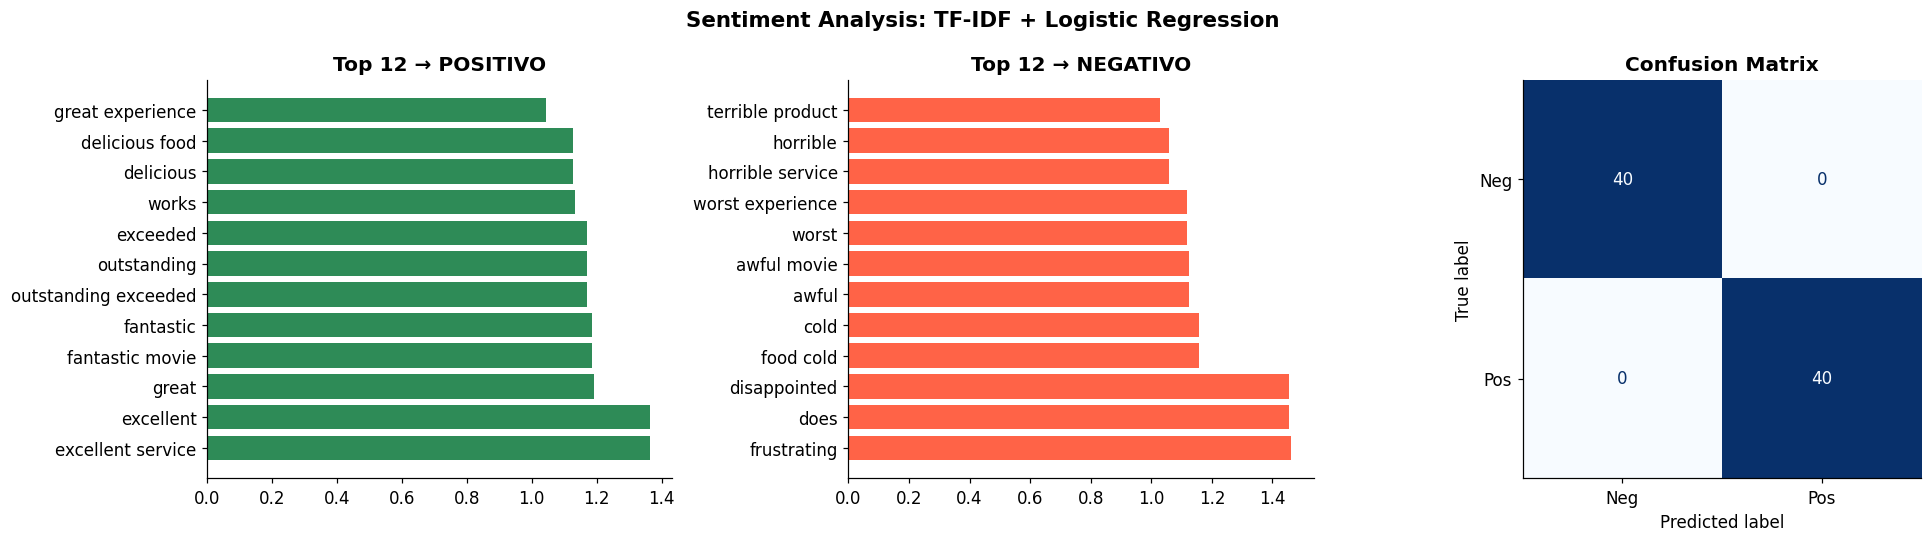

              precision    recall  f1-score   support

    Negativo       1.00      1.00      1.00        40
    Positivo       1.00      1.00      1.00        40

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80

5-Fold CV F1: 1.0000 ± 0.0000


In [28]:
# --- Features discriminativas + Evaluacion final ---
vec_f = TfidfVectorizer(max_features=3000, ngram_range=(1,2),
                         stop_words='english', sublinear_tf=True)
clf_f = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
Xtr_f = vec_f.fit_transform(X_tr); Xte_f = vec_f.transform(X_te)
clf_f.fit(Xtr_f, y_tr)

coef = clf_f.coef_[0]; vocab = np.array(vec_f.get_feature_names_out())
top_p = np.argsort(coef)[-12:][::-1]; top_n = np.argsort(coef)[:12]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].barh(range(12), coef[top_p], color='seagreen')
axes[0].set_yticks(range(12)); axes[0].set_yticklabels(vocab[top_p])
axes[0].set_title('Top 12 → POSITIVO', fontweight='bold')

axes[1].barh(range(12), np.abs(coef[top_n]), color='tomato')
axes[1].set_yticks(range(12)); axes[1].set_yticklabels(vocab[top_n])
axes[1].set_title('Top 12 → NEGATIVO', fontweight='bold')

yp_f = clf_f.predict(Xte_f)
cm = confusion_matrix(y_te, yp_f)
ConfusionMatrixDisplay(cm, display_labels=['Neg','Pos']).plot(ax=axes[2], colorbar=False, cmap='Blues')
axes[2].set_title('Confusion Matrix', fontweight='bold')

plt.suptitle('Sentiment Analysis: TF-IDF + Logistic Regression', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print(classification_report(y_te, yp_f, target_names=['Negativo','Positivo']))
nlp_pipe = Pipeline([('tfidf', TfidfVectorizer(max_features=3000, ngram_range=(1,2),
                       stop_words='english', sublinear_tf=True)),
                      ('clf', LogisticRegression(max_iter=1000, random_state=42))])
cv_f1 = cross_val_score(nlp_pipe, X_tw, y_tw, cv=5, scoring='f1')
print(f"5-Fold CV F1: {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")


---
# Bloque 10

## Resumen Teorico por Modelo

| Modelo | Tipo | Loss | Parametros | Hiperparametros | Supuestos |
|--------|------|------|------------|-----------------|-----------|
| **KNN** | No-param | — | Ninguno | K, metrica | Lipschitz η, metrica definida |
| **Lin. Reg.** | Param | MSE | θ₀...θₚ | α (GD), λ (Ridge) | Gauss-Markov (5 supuestos) |
| **Log. Reg.** | Param | Cross-Entropy | θ₀...θₚ | C = 1/λ | Linealidad en log-odds |
| **Decision Tree** | No-param | Gini/Entropia (local) | Splits, labels | max_depth, min_samples | Greedy, no optimo global |
| **Random Forest** | Ensemble | Promedio de arboles | Multiples arboles | n_estimators, max_features | Bootstrap + feature sampling |
| **Naive Bayes** | Param | Log-likelihood | P(y), P(xᵢ\|y) | α (Laplace) | Independencia condicional |

| Area | Clasico | Estado del Arte | Referencia |
|------|---------|-----------------|------------|
| **Tabular** | RF, XGBoost | XGBoost, LightGBM, CatBoost | Kaggle: boosting gana ~80% |
| **NLP** | TF-IDF + LR | Transformers (BERT, GPT-4, LLaMA) | "Attention is All You Need" (2017) |
| **Vision** | HOG + SVM | ViT, ResNet, CLIP | ImageNet revolution |
| **Time Series** | ARIMA | Temporal Fusion Transformers | N-BEATS, TimeGPT |
| **Explicabilidad** | Coefs LR | SHAP values | Lundberg & Lee (2017) |

## NLP: De BoW a GPT

```
1990s: Regex + reglas manuales
2000s: Bag of Words + Naive Bayes / SVM
2013:  Word2Vec (Mikolov) — embeddings semanticos
2017:  Attention is All You Need — Transformers
2018:  BERT (Google) — pretraining bidireccional
2020:  GPT-3 (OpenAI) — few-shot learning
2023:  GPT-4, LLaMA, Claude — razonamiento avanzado
2024+: Agentes, multimodal, RAG
```

## Recursos

- **Shalev-Shwartz & Ben-David** — *Understanding ML* (teoria formal)
- **ISLP** — James et al. (aplicaciones con Python)
- **CS-229 Stanford** — https://stanford.edu/~shervine/teaching/cs-229/
- **fast.ai** — https://www.fast.ai
- **Carolyn Wang** — Guia de exploracion ML/NLP para principiantes
- **taha7ussein007/MachineLearning_Practices** — GitHub
